# Análise de Sensibilidade

A análise de sensibilidade avalia se a arquitectura depende fortemente de escolhas
específicas de hiperparâmetros. Foram testadas variações controladas em três elementos:
regularização do Ridge no Nível 1, número de estimadores dos modelos ensemble do Nível 0,
e threshold de Pearson na seleção de features.

O resultado da Fase 3b (configuração default) é usado como referência fixa - não é re-executado. No total, são avaliadas 7 configurações: a configuração default da Fase 3b e 6 configurações alternativas executadas neste notebook:

| Bloco | Hiperparâmetro | Valores testados | Default (Fase 3b) |
|---|---|---|---|
| A | Ridge `alpha` | 0.1, 10.0 | **1.0** |
| B | Nível 0 `n_estimators` | 50, 200 | **100** |
| C | Pearson `threshold` | 0.01, 0.05 | **0.03** |

Em cada bloco varia-se apenas o parâmetro em análise, mantendo os restantes no valor default.

## 1. Setup e Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import time

from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import xgboost as xgb

SEED = 42
np.random.seed(SEED)

PATH = 'generated_dataset_ext.csv'

FOLDS = [
    {'train_months': [1],             'test_months': [2]},
    {'train_months': [1,2],           'test_months': [3]},
    {'train_months': [1,2,3],         'test_months': [4,5]},
    {'train_months': [1,2,3,4,5],     'test_months': [6,7]},
    {'train_months': [1,2,3,4,5,6,7], 'test_months': [8]},
]

ICAO_CORR    = 95.0
FUEL_KG_KM   = 4.5
CO2_PER_FUEL = 3.16

# Referência fixa - resultados da Fase 3b (não re-executado)
REF = {
    'label':       'default (Fase 3b)',
    'alpha':       1.0,
    'n_estimators':100,
    'pearson_thr': 0.03,
    'rmse_cost':   39.17,
    'rmse_dur':    14.01,
    'rmse_co2':    95.95,
    'n_feats_cost':12,
    'n_feats_dur': 17,
    'n_feats_co2': 10,
}

print('Imports OK')
print(f'Referência - Custo: {REF["rmse_cost"]} | Duração: {REF["rmse_dur"]} | CO₂: {REF["rmse_co2"]}')

Imports OK
Referência - Custo: 39.17 | Duração: 14.01 | CO₂: 95.95


## 2. Carregamento e pré-processamento

In [7]:
df = pd.read_csv(PATH, low_memory=False)
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
df['jet_fuel_price_usd'] = df['jet_fuel_price_usd'].bfill().ffill()
df = df.sort_values('FL_DATE').reset_index(drop=True)

TARGET_COST     = 'COST_PRED_USD'
TARGET_DURATION = 'DURATION_REAL_MIN'
TARGET_CO2      = 'CO2_kg'
TARGETS = [TARGET_COST, TARGET_DURATION, TARGET_CO2]

FEATURES_CAT = ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'Season']
FEATURES_NUM_BASE = [
    'haversine_distance', 'route_nonlinearity',
    'Month', 'DayofWeek', 'DayofMonth', 'Quarter',
    'IsWeekend', 'IsNightFlight',
    'CRS_ELAPSED_TIME', 'DEP_HOUR', 'Rolling_DEP_DELAY',
    'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
]
BASE = FEATURES_CAT + FEATURES_NUM_BASE

CANDIDATES_COST = BASE + [
    'jet_fuel_price_usd', 'carbon_price_usd',
    'load_factor_prev_month', 'hist_route_price', 'is_holiday',
]
CANDIDATES_DUR = BASE + [
    'load_factor_prev_month', 'is_holiday',
    'temp_origin_c', 'temp_dest_c',
    'precip_origin_mm', 'precip_dest_mm',
    'wind_origin_kmh', 'wind_dest_kmh',
    'extreme_temp_origin', 'extreme_temp_dest',
    'heavy_rain_origin', 'heavy_rain_dest',
    'strong_wind_origin', 'strong_wind_dest',
]
CANDIDATES_CO2 = BASE

ALL_CANDIDATES = list(dict.fromkeys(CANDIDATES_COST + CANDIDATES_DUR + CANDIDATES_CO2))
available = [f for f in ALL_CANDIDATES if f in df.columns]

df_model = df[available + TARGETS].copy()
le_dict = {}
for col in FEATURES_CAT:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

df_model['Month'] = df['Month'].values

icao_pred_all = ((df['haversine_distance'] + ICAO_CORR) * FUEL_KG_KM * CO2_PER_FUEL).values

candidates_per_target = {
    TARGET_COST:     [f for f in CANDIDATES_COST if f in df_model.columns],
    TARGET_DURATION: [f for f in CANDIDATES_DUR  if f in df_model.columns],
    TARGET_CO2:      [f for f in CANDIDATES_CO2  if f in df_model.columns],
}

print(f'Dataset: {df_model.shape}')
print(f'Candidatas - Custo: {len(candidates_per_target[TARGET_COST])} | '
      f'Duração: {len(candidates_per_target[TARGET_DURATION])} | '
      f'CO₂: {len(candidates_per_target[TARGET_CO2])}')

Dataset: (195950, 39)
Candidatas - Custo: 24 | Duração: 33 | CO₂: 19


## 3. Funções auxiliares

In [8]:
def select_features(df_m, feature_cols, target_col, pearson_thr=0.03, top_n_rf=12):
    X = df_m[feature_cols]
    y = df_m[target_col]
    pearson = X.corrwith(y).abs()
    pearson_sel = set(pearson[pearson >= pearson_thr].index)
    sc = StandardScaler()
    X_sc = sc.fit_transform(X)
    lasso = LassoCV(cv=5, max_iter=5000, random_state=SEED, n_jobs=-1)
    lasso.fit(X_sc, y)
    coef = pd.Series(np.abs(lasso.coef_), index=feature_cols)
    lasso_sel = set(coef[coef > 0].index)
    rf_s = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
    rf_s.fit(X, y)
    imp = pd.Series(rf_s.feature_importances_, index=feature_cols)
    rf_sel = set(imp.nlargest(top_n_rf).index)
    summary = pd.DataFrame({
        'feature': feature_cols,
        'votes': [sum([f in pearson_sel, f in lasso_sel, f in rf_sel]) for f in feature_cols]
    })
    return summary[summary['votes'] >= 2]['feature'].tolist()


def walk_forward_oof(models_dict, df_m, y_series, feature_cols, folds, scale=False):
    n = len(df_m)
    oof_matrix = np.zeros((n, len(models_dict)))
    oof_mask   = np.zeros(n, dtype=bool)
    for fold in folds:
        tr_mask = df_m['Month'].isin(fold['train_months']).values
        te_mask = df_m['Month'].isin(fold['test_months']).values
        X_tr_raw = df_m.loc[tr_mask, feature_cols].values
        X_te_raw = df_m.loc[te_mask, feature_cols].values
        y_tr     = y_series.values[tr_mask]
        if scale:
            sc_ = StandardScaler()
            X_tr = sc_.fit_transform(X_tr_raw)
            X_te = sc_.transform(X_te_raw)
        else:
            X_tr, X_te = X_tr_raw, X_te_raw
        for j, (name, model) in enumerate(models_dict.items()):
            model.fit(X_tr, y_tr)
            oof_matrix[np.where(te_mask)[0], j] = model.predict(X_te)
        oof_mask[te_mask] = True
    return oof_matrix, oof_mask


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print('Funções auxiliares prontas.')

Funções auxiliares prontas.


## 4. Função principal da arquitetura

In [9]:
FEATS_L1_COST = [f for f in [
    'haversine_distance','route_nonlinearity','Month','DayofWeek','Quarter','IsWeekend',
    'CRS_ELAPSED_TIME','DEP_HOUR','Rolling_DEP_DELAY',
    'jet_fuel_price_usd','carbon_price_usd','load_factor_prev_month',
    'is_holiday','hist_route_price',
] if f in df_model.columns]

FEATS_L1_DUR = [f for f in [
    'haversine_distance','route_nonlinearity','Month','DayofWeek','Quarter','IsWeekend',
    'CRS_ELAPSED_TIME','DEP_HOUR','Rolling_DEP_DELAY',
    'load_factor_prev_month','is_holiday',
    'temp_origin_c','temp_dest_c','precip_origin_mm','precip_dest_mm',
    'wind_origin_kmh','wind_dest_kmh',
    'extreme_temp_origin','extreme_temp_dest',
    'heavy_rain_origin','heavy_rain_dest','strong_wind_origin','strong_wind_dest',
] if f in df_model.columns]

FEATS_L1_CO2 = [f for f in [
    'haversine_distance','route_nonlinearity','Month','DayofWeek','Quarter','IsWeekend',
    'CRS_ELAPSED_TIME','DEP_HOUR','Rolling_DEP_DELAY',
] if f in df_model.columns]


def run_architecture(alpha=1.0, n_estimators=100, pearson_thr=0.03, label=''):
    t0 = time.time()
    lbl = label or f'alpha={alpha} n_est={n_estimators} pear={pearson_thr}'
    print(f'  [{lbl}] a correr...', end=' ', flush=True)

    # Seleção de features
    feats = {}
    for target in TARGETS:
        feats[target] = select_features(
            df_model, candidates_per_target[target], target, pearson_thr=pearson_thr)

    # Nível 0 - Custo
    X = df_model[list(dict.fromkeys(
        feats[TARGET_COST] + feats[TARGET_DURATION] + feats[TARGET_CO2] + ['Month']
    ))].copy()

    oof_cost, mask_cost = walk_forward_oof(
        {'LR': LinearRegression(),
         'RF': RandomForestRegressor(n_estimators=n_estimators, random_state=SEED, n_jobs=-1),
         'XGB': xgb.XGBRegressor(n_estimators=n_estimators, random_state=SEED, verbosity=0)},
        X, df_model[TARGET_COST], feats[TARGET_COST], FOLDS, scale=True)

    # Nível 0 - Duração
    oof_dur, mask_dur = walk_forward_oof(
        {'RF': RandomForestRegressor(n_estimators=n_estimators, random_state=SEED, n_jobs=-1),
         'LinSVR': LinearSVR(C=1.0, max_iter=3000, random_state=SEED),
         'XGB': xgb.XGBRegressor(n_estimators=n_estimators, random_state=SEED, verbosity=0)},
        X, df_model[TARGET_DURATION], feats[TARGET_DURATION], FOLDS, scale=True)

    # Nível 0 - CO₂
    oof_co2_ml, _ = walk_forward_oof(
        {'RF': RandomForestRegressor(n_estimators=n_estimators, random_state=SEED, n_jobs=-1),
         'XGB': xgb.XGBRegressor(n_estimators=n_estimators, random_state=SEED, verbosity=0)},
        X, df_model[TARGET_CO2], feats[TARGET_CO2], FOLDS, scale=True)
    oof_co2 = np.column_stack([icao_pred_all, oof_co2_ml])

    # Nível 1 - Ridge
    oof_idx = np.where(mask_cost)[0]

    def build_meta(oof_base, feats_l1, cross1, cross2):
        X_l1 = df_model.iloc[oof_idx][feats_l1].values
        X_l1_sc = StandardScaler().fit_transform(X_l1)
        m1 = cross1[oof_idx].mean(axis=1, keepdims=True)
        m2 = cross2[oof_idx].mean(axis=1, keepdims=True)
        return np.hstack([oof_base[oof_idx], X_l1_sc, m1, m2])

    y_c = df_model[TARGET_COST].values[oof_idx]
    y_d = df_model[TARGET_DURATION].values[oof_idx]
    y_e = df_model[TARGET_CO2].values[oof_idx]

    X_mc = build_meta(oof_cost, FEATS_L1_COST, oof_dur,  oof_co2)
    X_md = build_meta(oof_dur,  FEATS_L1_DUR,  oof_cost, oof_co2)
    X_me = build_meta(oof_co2,  FEATS_L1_CO2,  oof_cost, oof_dur)

    r_c = Ridge(alpha=alpha); r_c.fit(X_mc, y_c)
    r_d = Ridge(alpha=alpha); r_d.fit(X_md, y_d)
    r_e = Ridge(alpha=alpha); r_e.fit(X_me, y_e)

    rc = rmse(y_c, r_c.predict(X_mc))
    rd = rmse(y_d, r_d.predict(X_md))
    re = rmse(y_e, r_e.predict(X_me))

    elapsed = time.time() - t0
    print(f'OK ({elapsed/60:.1f}min) | custo={rc:.2f} dur={rd:.2f} co2={re:.2f}')

    return {
        'label': lbl, 'alpha': alpha,
        'n_estimators': n_estimators, 'pearson_thr': pearson_thr,
        'rmse_cost': rc, 'rmse_dur': rd, 'rmse_co2': re,
        'n_feats_cost': len(feats[TARGET_COST]),
        'n_feats_dur':  len(feats[TARGET_DURATION]),
        'n_feats_co2':  len(feats[TARGET_CO2]),
    }

print('Função run_architecture pronta.')
print('6 runs a executar')

Função run_architecture pronta.
6 runs a executar


## 5. Bloco A - Ridge alpha ∈ {0.1, 10.0}

In [10]:
print('=== BLOCO A - Ridge alpha (default=1.0) ===')
print()
res_alpha_01 = run_architecture(
    alpha=0.1, n_estimators=100, pearson_thr=0.03,
    label='alpha=0.1'
)

res_alpha_10 = run_architecture(
    alpha=10.0, n_estimators=100, pearson_thr=0.03,
    label='alpha=10.0'
)

results_A = [res_alpha_01, REF.copy(), res_alpha_10]

df_A = pd.DataFrame(results_A)[['label','rmse_cost','rmse_dur','rmse_co2']]
df_A.columns = ['Configuração','RMSE Custo (USD)','RMSE Duração (min)','RMSE CO₂ (kg)']
print()
print(df_A.to_string(index=False))

=== BLOCO A - Ridge alpha (default=1.0) ===

  [alpha=0.1] a correr... OK (7.7min) | custo=39.17 dur=14.01 co2=95.95
  [alpha=10.0] a correr... OK (7.7min) | custo=39.17 dur=14.01 co2=95.95

     Configuração  RMSE Custo (USD)  RMSE Duração (min)  RMSE CO₂ (kg)
        alpha=0.1         39.169743           14.008686      95.949102
default (Fase 3b)         39.170000           14.010000      95.950000
       alpha=10.0         39.169926           14.008730      95.949111


## 6. Bloco B - n_estimators dos modelos ensemble do Nível 0 ∈ {50, 200}

In [11]:
print('=== BLOCO B - n_estimators dos modelos ensemble do Nível 0 (default=100) ===')
print()
res_n50 = run_architecture(
    alpha=1.0, n_estimators=50, pearson_thr=0.03,
    label='n_est=50'
)

res_n200 = run_architecture(
    alpha=1.0, n_estimators=200, pearson_thr=0.03,
    label='n_est=200'
)

results_B = [res_n50, REF.copy(), res_n200]

df_B = pd.DataFrame(results_B)[['label','rmse_cost','rmse_dur','rmse_co2']]
df_B.columns = ['Configuração','RMSE Custo (USD)','RMSE Duração (min)','RMSE CO₂ (kg)']
print()
print(df_B.to_string(index=False))

=== BLOCO B - n_estimators dos modelos ensemble do Nível 0 (default=100) ===

  [n_est=50] a correr... OK (4.8min) | custo=39.11 dur=14.01 co2=100.71
  [n_est=200] a correr... OK (13.7min) | custo=39.28 dur=14.01 co2=91.67

     Configuração  RMSE Custo (USD)  RMSE Duração (min)  RMSE CO₂ (kg)
         n_est=50         39.114584           14.009685     100.705144
default (Fase 3b)         39.170000           14.010000      95.950000
        n_est=200         39.277950           14.007419      91.668990


## 7. Bloco C - Pearson threshold ∈ {0.01, 0.05}

In [12]:
print('=== BLOCO C - Pearson threshold (default=0.03) ===')
print()
res_thr001 = run_architecture(
    alpha=1.0, n_estimators=100, pearson_thr=0.01,
    label='pearson=0.01'
)

res_thr005 = run_architecture(
    alpha=1.0, n_estimators=100, pearson_thr=0.05,
    label='pearson=0.05'
)

results_C = [res_thr001, REF.copy(), res_thr005]

df_C = pd.DataFrame(results_C)[['label','rmse_cost','rmse_dur','rmse_co2',
                                  'n_feats_cost','n_feats_dur','n_feats_co2']]
df_C.columns = ['Configuração','RMSE Custo','RMSE Duração','RMSE CO₂',
                 'N feats custo','N feats dur','N feats CO₂']
print()
print(df_C.to_string(index=False))

=== BLOCO C - Pearson threshold (default=0.03) ===

  [pearson=0.01] a correr... OK (8.7min) | custo=39.20 dur=14.00 co2=99.58
  [pearson=0.05] a correr... OK (7.9min) | custo=39.17 dur=14.02 co2=95.96

     Configuração  RMSE Custo  RMSE Duração  RMSE CO₂  N feats custo  N feats dur  N feats CO₂
     pearson=0.01   39.197219     14.000815 99.580354             16           20           12
default (Fase 3b)   39.170000     14.010000 95.950000             12           17           10
     pearson=0.05   39.170824     14.017343 95.959105             12           16           10


## 8. Tabela consolidada com Δ% face ao default

In [13]:
ref_cost = REF['rmse_cost']
ref_dur  = REF['rmse_dur']
ref_co2  = REF['rmse_co2']

all_results = []
for bloco, results in [('A - Ridge alpha', results_A),
                        ('B - Ensemble n_estimators', results_B),
                        ('C - Pearson threshold', results_C)]:
    for r in results:
        dc = (r['rmse_cost'] - ref_cost) / ref_cost * 100
        dd = (r['rmse_dur']  - ref_dur)  / ref_dur  * 100
        de = (r['rmse_co2']  - ref_co2)  / ref_co2  * 100
        all_results.append({
            'Bloco': bloco,
            'Configuração': r['label'],
            'RMSE Custo': r['rmse_cost'],
            'Δ Custo %': dc,
            'RMSE Duração': r['rmse_dur'],
            'Δ Duração %': dd,
            'RMSE CO₂': r['rmse_co2'],
            'Δ CO₂ %': de,
        })

df_all = pd.DataFrame(all_results)

print('Tabela consolidada (Δ% face ao default da Fase 3b):')
print()
for bloco in df_all['Bloco'].unique():
    sub = df_all[df_all['Bloco'] == bloco]
    print(f'Bloco {bloco}:')
    print(f'  {"Config":<20} {"Custo":>10} {"Δ%":>8} {"Duração":>10} {"Δ%":>8} {"CO₂":>10} {"Δ%":>8}')
    print('  ' + '-'*72)
    for _, row in sub.iterrows():
        marker = ' <- ref' if row['Configuração'] == 'default (Fase 3b)' else ''
        print(f'  {row["Configuração"]:<20} {row["RMSE Custo"]:>10.3f} {row["Δ Custo %"]:>+7.1f}% '
              f'{row["RMSE Duração"]:>10.3f} {row["Δ Duração %"]:>+7.1f}% '
              f'{row["RMSE CO₂"]:>10.3f} {row["Δ CO₂ %"]:>+7.1f}%{marker}')
    print()

Tabela consolidada (Δ% face ao default da Fase 3b):

Bloco A - Ridge alpha:
  Config                    Custo       Δ%    Duração       Δ%        CO₂       Δ%
  ------------------------------------------------------------------------
  alpha=0.1                39.170    -0.0%     14.009    -0.0%     95.949    -0.0%
  default (Fase 3b)        39.170    +0.0%     14.010    +0.0%     95.950    +0.0% <- ref
  alpha=10.0               39.170    -0.0%     14.009    -0.0%     95.949    -0.0%

Bloco B - Ensemble n_estimators:
  Config                    Custo       Δ%    Duração       Δ%        CO₂       Δ%
  ------------------------------------------------------------------------
  n_est=50                 39.115    -0.1%     14.010    -0.0%    100.705    +5.0%
  default (Fase 3b)        39.170    +0.0%     14.010    +0.0%     95.950    +0.0% <- ref
  n_est=200                39.278    +0.3%     14.007    -0.0%     91.669    -4.5%

Bloco C - Pearson threshold:
  Config                    Cust

## 9. Visualização

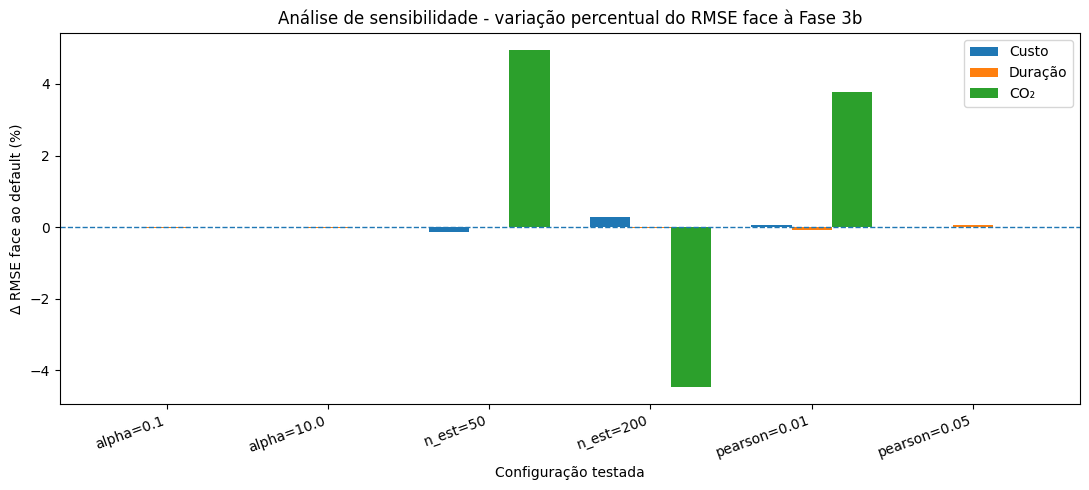

In [20]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_all.copy()

# Remover as linhas default, porque são sempre 0%
df_plot_alt = df_plot[~df_plot["Configuração"].str.contains("default", case=False, na=False)].copy()

# Ordem desejada das configurações
order = [
    "alpha=0.1",
    "alpha=10.0",
    "n_est=50",
    "n_est=200",
    "pearson=0.01",
    "pearson=0.05"
]

df_plot_alt["Configuração"] = pd.Categorical(
    df_plot_alt["Configuração"],
    categories=order,
    ordered=True
)

df_plot_alt = df_plot_alt.sort_values("Configuração")

x = np.arange(len(df_plot_alt))
width = 0.25

plt.figure(figsize=(11, 5))

plt.bar(x - width, df_plot_alt["Δ Custo %"], width, label="Custo")
plt.bar(x, df_plot_alt["Δ Duração %"], width, label="Duração")
plt.bar(x + width, df_plot_alt["Δ CO₂ %"], width, label="CO₂")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(x, df_plot_alt["Configuração"], rotation=20, ha="right")
plt.ylabel("Δ RMSE face ao default (%)")
plt.xlabel("Configuração testada")
plt.title("Análise de sensibilidade - variação percentual do RMSE face à Fase 3b")
plt.legend()
plt.tight_layout()

plt.savefig("fig_sensitivity_delta_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
df_A.to_csv("sensitivity_alpha.csv", index=False)
df_B.to_csv("sensitivity_rf_estimators.csv", index=False)
df_C.to_csv("sensitivity_pearson_threshold.csv", index=False)
df_all.to_csv("sensitivity_all_results.csv", index=False)

print("Tabelas exportadas.")

Tabelas exportadas.


## 10. Resumo

In [16]:
print('Resumo: Análise de Sensibilidade')
print(f'Referência Fase 3b: Custo={ref_cost:.3f} | Duração={ref_dur:.3f} | CO₂={ref_co2:.3f}')
print()
for bloco, results in [('A - Ridge alpha', results_A),
                        ('B - Ensemble n_estimators', results_B),
                        ('C - Pearson threshold', results_C)]:
    alts = [r for r in results if r['label'] != 'default (Fase 3b)']
    dc = max(abs((r['rmse_cost']-ref_cost)/ref_cost*100) for r in alts)
    dd = max(abs((r['rmse_dur'] -ref_dur) /ref_dur *100) for r in alts)
    de = max(abs((r['rmse_co2'] -ref_co2) /ref_co2 *100) for r in alts)
    print(f'Bloco {bloco}:')
    print(f'  Variação máx. Custo:   {dc:.2f}%')
    print(f'  Variação máx. Duração: {dd:.2f}%')
    print(f'  Variação máx. CO₂:     {de:.2f}%')
    print()

Resumo: Análise de Sensibilidade
Referência Fase 3b: Custo=39.170 | Duração=14.010 | CO₂=95.950

Bloco A - Ridge alpha:
  Variação máx. Custo:   0.00%
  Variação máx. Duração: 0.01%
  Variação máx. CO₂:     0.00%

Bloco B - Ensemble n_estimators:
  Variação máx. Custo:   0.28%
  Variação máx. Duração: 0.02%
  Variação máx. CO₂:     4.96%

Bloco C - Pearson threshold:
  Variação máx. Custo:   0.07%
  Variação máx. Duração: 0.07%
  Variação máx. CO₂:     3.78%



In [17]:
summary_rows = []

for bloco, results in [
    ('A - Ridge alpha', results_A),
    ('B - Ensemble n_estimators', results_B),
    ('C - Pearson threshold', results_C)
]:
    alts = [r for r in results if r['label'] != 'default (Fase 3b)']

    summary_rows.append({
        'Bloco': bloco,
        'Max Δ Custo %': max(abs((r['rmse_cost'] - ref_cost) / ref_cost * 100) for r in alts),
        'Max Δ Duração %': max(abs((r['rmse_dur'] - ref_dur) / ref_dur * 100) for r in alts),
        'Max Δ CO₂ %': max(abs((r['rmse_co2'] - ref_co2) / ref_co2 * 100) for r in alts),
    })

df_sensitivity_summary = pd.DataFrame(summary_rows)
df_sensitivity_summary.to_csv("sensitivity_summary_max_variation.csv", index=False)

df_sensitivity_summary

,Bloco,Max Δ Custo %,Max Δ Duração %,Max Δ CO₂ %
0,A - Ridge alpha,0.000656,0.009379,0.000936
1,B - Ensemble n_estimators,0.275593,0.018423,4.955856
2,C - Pearson threshold,0.069489,0.065560,3.783590
